# 1D Conditional Diffusion for Post-Digitization ECG Refinement

This notebook contains the complete end-to-end training loop for your Master's Thesis. It takes the noisy 1D signals extracted by the optical digitizer (like VinDigitizer/PhysioNet Baseline) and uses a 1D Conditional Denoising Diffusion Probabilistic Model (cDDPM) to "Super-Resolve" them back to the clean biological manifold.

### Instructions for Google Colab:
1. Go to **Runtime -> Change runtime type** and select **T4 GPU**.
2. Upload your `cleannew2.npy` and `noisynew2.npy` files to the Colab files pane (left side), or mount your Google Drive.
3. Run all cells!

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import math
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Optional: If your data is in Google Drive, uncomment the following lines to mount it:
# from google.colab import drive
# drive.mount('/content/drive')
# PATH_CLEAN = '/content/drive/MyDrive/cleannew2.npy'
# PATH_NOISY = '/content/drive/MyDrive/noisynew2.npy'

# If uploading directly to the Colab session, use these paths:
PATH_CLEAN = '/content/clean_5000_baseline.npy'
PATH_NOISY = '/content/noisy_5000_baseline.npy'

Using device: cuda


## 1. Dataset Loader
Loads your 1250-length aligned arrays.

In [10]:
class RealECGDataset(Dataset):
    def __init__(self, clean_npy_path, noisy_npy_path):
        if not os.path.exists(clean_npy_path) or not os.path.exists(noisy_npy_path):
            raise FileNotFoundError(f"Please upload {clean_npy_path} and {noisy_npy_path} to Colab.")

        print(f"Loading data...")
        self.clean_data = np.load(clean_npy_path).astype(np.float32)
        self.noisy_data = np.load(noisy_npy_path).astype(np.float32)

        # Ensure shape is (N, 1, 1250)
        if len(self.clean_data.shape) == 2:
            self.clean_data = np.expand_dims(self.clean_data, axis=1)
            self.noisy_data = np.expand_dims(self.noisy_data, axis=1)

        print(f"Dataset loaded! Shape: {self.clean_data.shape}")

    def __len__(self):
        return len(self.clean_data)

    def __getitem__(self, idx):
        clean = torch.tensor(self.clean_data[idx])
        noisy = torch.tensor(self.noisy_data[idx])
        return clean, noisy

## 2. Model Architecture (1D Conditional U-Net)
Takes the noisy signal as a condition to guide the diffusion reverse process.

In [11]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block1D(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU()
        )

    def forward(self, x, t):
        time_emb = self.mlp(t).unsqueeze(-1)
        return self.conv(x) + time_emb

class ConditionalUNet1D(nn.Module):
    def __init__(self, channels=1, time_emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )

        # Input channels = 2 (1 for diffused clean signal + 1 for noisy condition)
        self.init_conv = nn.Conv1d(channels * 2, 64, kernel_size=7, padding=3)

        self.downs = nn.ModuleList([
            Block1D(64, 128, time_emb_dim),
            Block1D(128, 256, time_emb_dim)
        ])

        self.pool = nn.MaxPool1d(2)
        self.mid = Block1D(256, 256, time_emb_dim)

        self.ups = nn.ModuleList([
            Block1D(512, 128, time_emb_dim), # Corrected: 256 (from upsampled x) + 256 (from skip_x)
            Block1D(256, 64, time_emb_dim)   # Corrected: 128 (from upsampled x) + 128 (from skip_x)
        ])

        self.up_sample = nn.Upsample(scale_factor=2, mode='linear', align_corners=False)
        self.final_conv = nn.Conv1d(64, channels, kernel_size=3, padding=1)

    def forward(self, x, t, cond):
        t = self.time_mlp(t)

        # Concatenate diffused signal and noisy optical extraction
        x = torch.cat([x, cond], dim=1)
        x = self.init_conv(x)

        skip_connections = []
        for down in self.downs:
            x = down(x, t)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.mid(x, t)

        for up in self.ups:
            x = self.up_sample(x)
            # Handle odd dimensions during upsampling
            skip_x = skip_connections.pop()
            if x.shape[-1] != skip_x.shape[-1]:
                x = F.pad(x, (0, skip_x.shape[-1] - x.shape[-1]))
            x = torch.cat((x, skip_x), dim=1)
            x = up(x, t)

        return self.final_conv(x)

## 3. Diffusion Process (DDPM)
Handles the forward noise scheduling and reverse sampling (inference).

In [12]:
def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

class GaussianDiffusion1D:
    def __init__(self, model, timesteps=1000):
        self.model = model
        self.timesteps = timesteps
        self.betas = linear_beta_schedule(timesteps)
        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

    def sample_timesteps(self, n, device):
        return torch.randint(low=1, high=self.timesteps, size=(n,), device=device)

    def add_noise(self, x_start, t):
        noise = torch.randn_like(x_start)
        alphas_cumprod_t = self.alphas_cumprod.to(x_start.device)[t].view(-1, 1, 1)
        x_noisy = torch.sqrt(alphas_cumprod_t) * x_start + torch.sqrt(1 - alphas_cumprod_t) * noise
        return x_noisy, noise

    def compute_loss(self, x_start, cond):
        device = x_start.device
        t = self.sample_timesteps(x_start.shape[0], device)
        x_noisy, noise = self.add_noise(x_start, t)
        predicted_noise = self.model(x_noisy, t, cond)
        return F.l1_loss(predicted_noise, noise)

    @torch.no_grad()
    def sample(self, cond):
        self.model.eval()
        device = cond.device
        b, c, l = cond.shape
        x = torch.randn((b, c, l), device=device)

        for i in reversed(range(1, self.timesteps)):
            t = (torch.ones(b) * i).long().to(device)
            predicted_noise = self.model(x, t, cond)

            alpha = self.alphas[i].to(device)
            alpha_cumprod = self.alphas_cumprod[i].to(device)
            beta = self.betas[i].to(device)

            if i > 1:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_cumprod))) * predicted_noise) + torch.sqrt(beta) * noise

        self.model.train()
        return x

## 4. Evaluation Metrics & Visualization
Calculates Median SNR and generates the plots for your thesis.

In [13]:
def calc_snr_med(clean, denoised):
    signal_power = torch.mean(clean**2, dim=-1)
    noise_power = torch.median((clean - denoised)**2, dim=-1).values
    noise_power = torch.clamp(noise_power, min=1e-8)
    snr = 10 * torch.log10(signal_power / noise_power)
    return snr.mean().item()

def plot_reconstruction(clean, noisy, denoised, epoch):
    clean_np = clean[0, 0].cpu().numpy()
    noisy_np = noisy[0, 0].cpu().numpy()
    denoised_np = denoised[0, 0].cpu().numpy()

    plt.figure(figsize=(15, 5))
    plt.plot(clean_np, label="Ground Truth (Clean)", color="green", alpha=0.8, linewidth=2)
    plt.plot(noisy_np, label="Digitizer Output (Noisy)", color="red", alpha=0.5, linestyle="--")
    plt.plot(denoised_np, label="Diffusion Output (Denoised)", color="blue", alpha=0.9, linewidth=1.5)
    plt.title(f"ECG Reconstruction at Epoch {epoch}")
    plt.legend()
    plt.show()

## 5. Training Loop
Run this to start training!

Loading data...
Dataset loaded! Shape: (2297, 1, 1250)
Epoch 1/50 | Loss: 0.1807
---> Val SNR_med: 13.11 dB


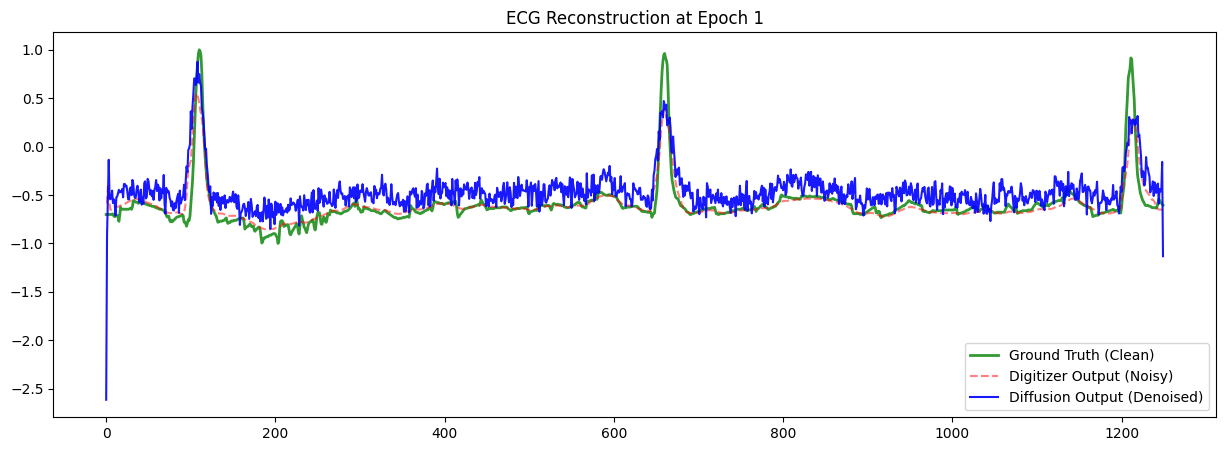

Epoch 2/50 | Loss: 0.0913
Epoch 3/50 | Loss: 0.0787
Epoch 4/50 | Loss: 0.0763
Epoch 5/50 | Loss: 0.0729
---> Val SNR_med: 17.58 dB


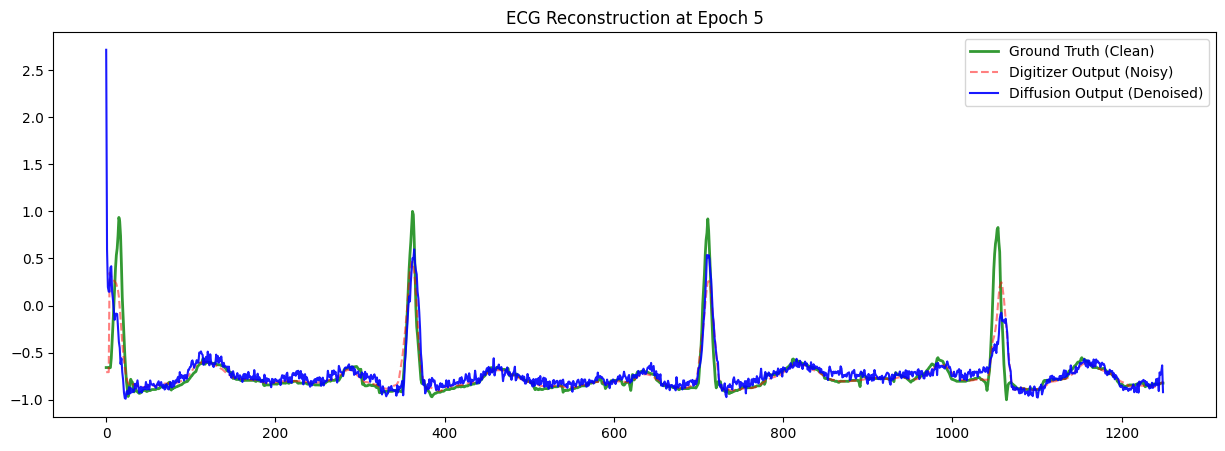

Epoch 6/50 | Loss: 0.0704
Epoch 7/50 | Loss: 0.0691
Epoch 8/50 | Loss: 0.0672
Epoch 9/50 | Loss: 0.0645
Epoch 10/50 | Loss: 0.0662
---> Val SNR_med: 19.04 dB


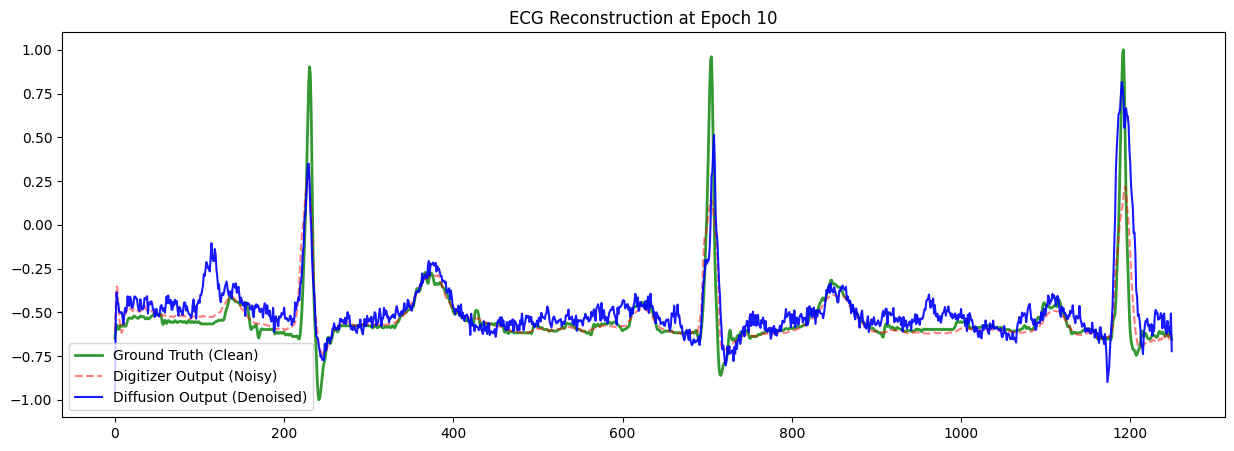

Epoch 11/50 | Loss: 0.0649
Epoch 12/50 | Loss: 0.0666
Epoch 13/50 | Loss: 0.0631
Epoch 14/50 | Loss: 0.0629
Epoch 15/50 | Loss: 0.0620
---> Val SNR_med: 23.51 dB


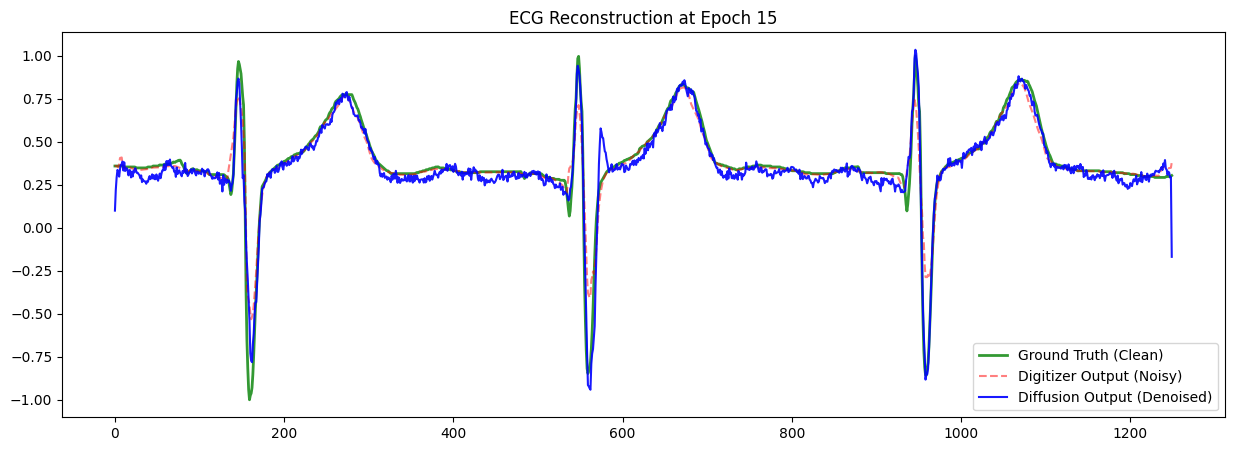

Epoch 16/50 | Loss: 0.0617
Epoch 17/50 | Loss: 0.0619
Epoch 18/50 | Loss: 0.0582
Epoch 19/50 | Loss: 0.0606
Epoch 20/50 | Loss: 0.0618
---> Val SNR_med: 23.37 dB


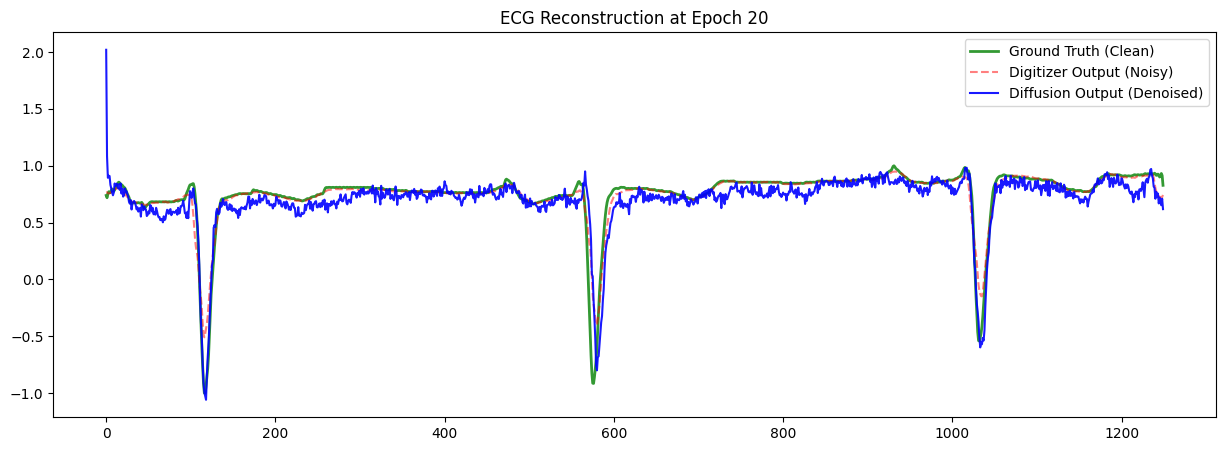

Epoch 21/50 | Loss: 0.0608
Epoch 22/50 | Loss: 0.0615
Epoch 23/50 | Loss: 0.0587
Epoch 24/50 | Loss: 0.0581
Epoch 25/50 | Loss: 0.0586
---> Val SNR_med: 25.66 dB


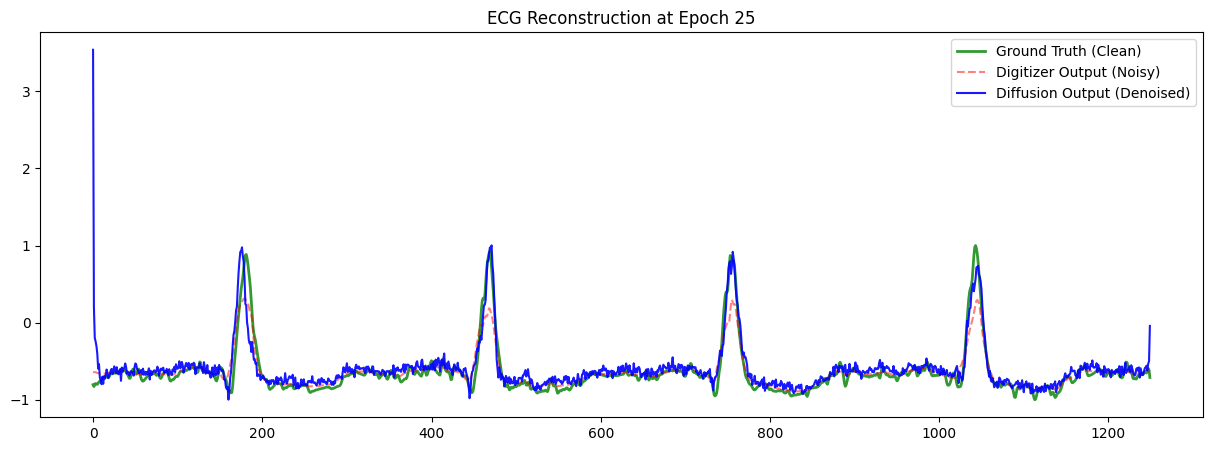

Epoch 26/50 | Loss: 0.0567
Epoch 27/50 | Loss: 0.0602
Epoch 28/50 | Loss: 0.0594
Epoch 29/50 | Loss: 0.0563
Epoch 30/50 | Loss: 0.0584
---> Val SNR_med: 24.82 dB


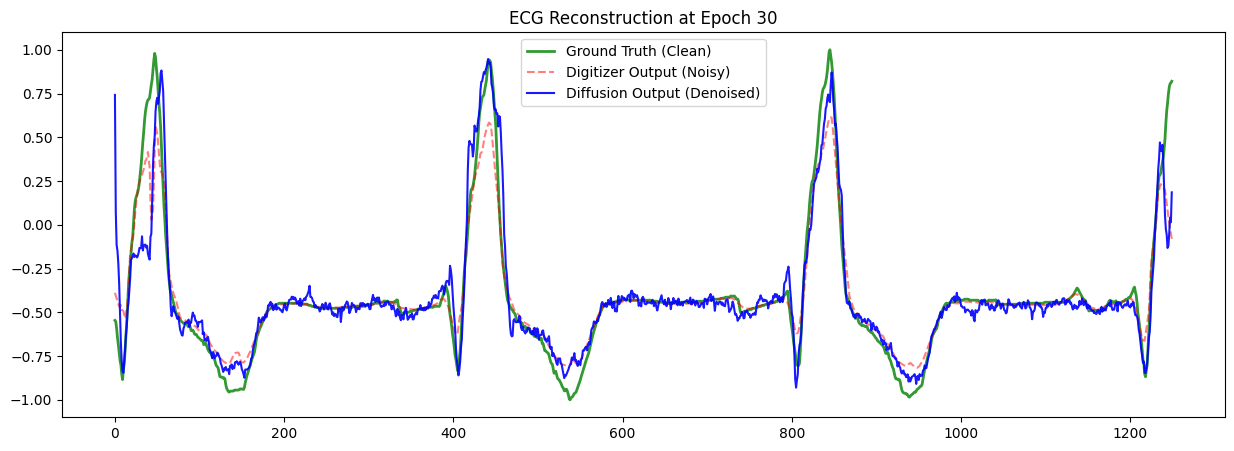

Epoch 31/50 | Loss: 0.0569
Epoch 32/50 | Loss: 0.0554
Epoch 33/50 | Loss: 0.0548
Epoch 34/50 | Loss: 0.0587
Epoch 35/50 | Loss: 0.0549
---> Val SNR_med: 24.59 dB


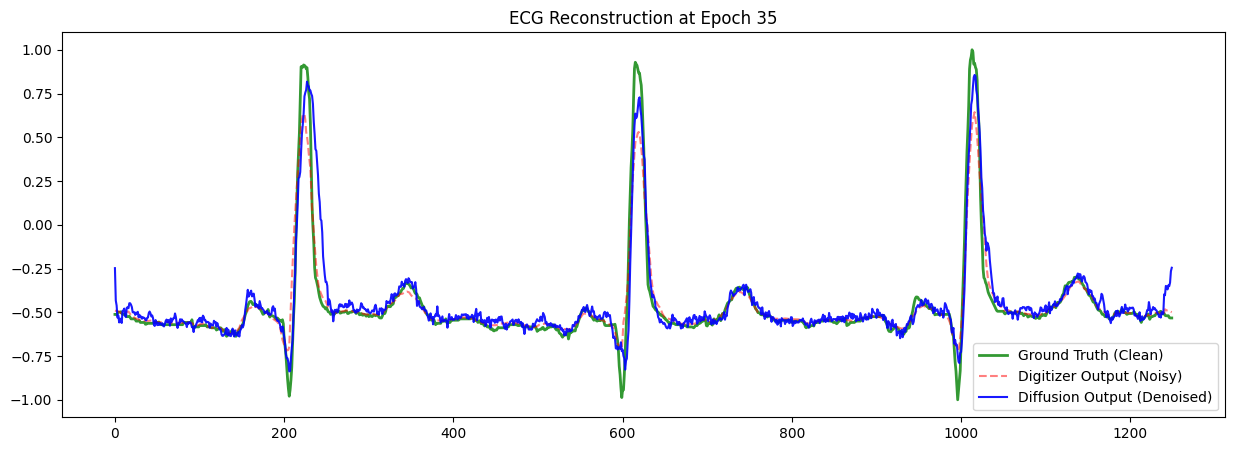

Epoch 36/50 | Loss: 0.0590
Epoch 37/50 | Loss: 0.0557
Epoch 38/50 | Loss: 0.0564
Epoch 39/50 | Loss: 0.0540
Epoch 40/50 | Loss: 0.0551
---> Val SNR_med: 23.98 dB


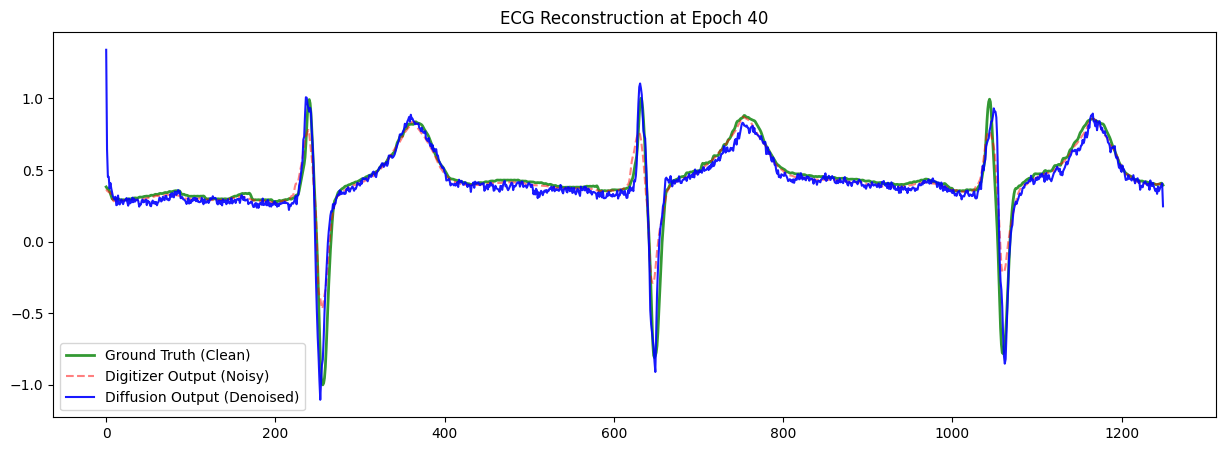

Epoch 41/50 | Loss: 0.0549
Epoch 42/50 | Loss: 0.0539
Epoch 43/50 | Loss: 0.0555
Epoch 44/50 | Loss: 0.0536
Epoch 45/50 | Loss: 0.0517
---> Val SNR_med: 20.71 dB


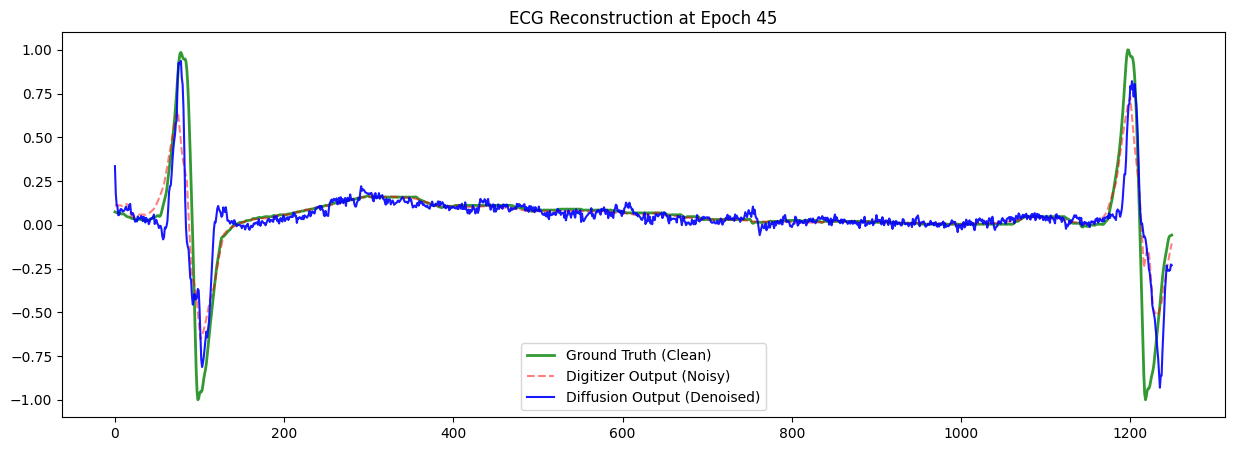

Epoch 46/50 | Loss: 0.0553
Epoch 47/50 | Loss: 0.0555
Epoch 48/50 | Loss: 0.0521
Epoch 49/50 | Loss: 0.0563
Epoch 50/50 | Loss: 0.0534
---> Val SNR_med: 19.67 dB


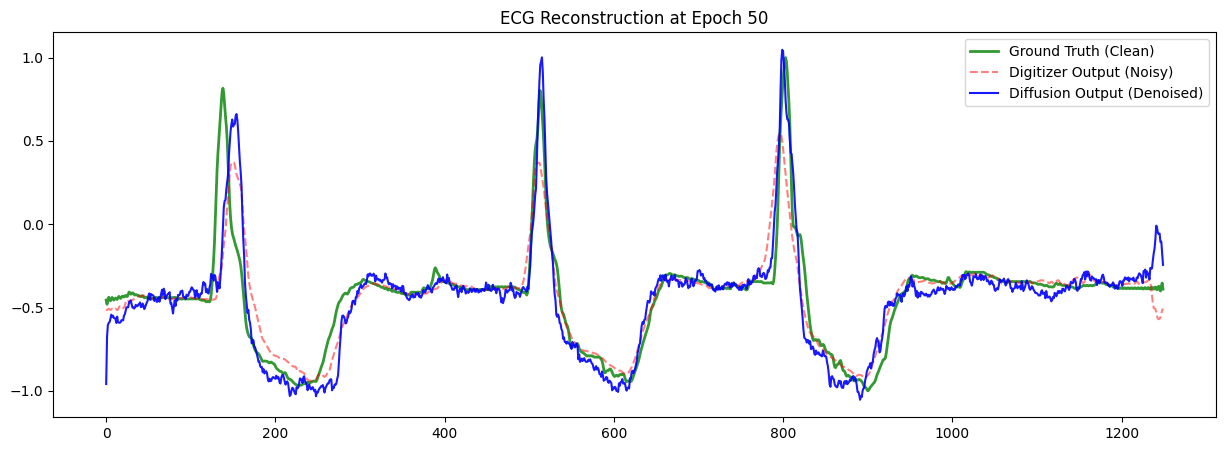

In [14]:
def train():
    try:
        dataset = RealECGDataset(PATH_CLEAN, PATH_NOISY)
    except FileNotFoundError as e:
        print(e)
        return

    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    # Initialize Model
    model = ConditionalUNet1D(channels=1).to(device)
    diffusion = GaussianDiffusion1D(model, timesteps=500)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)

    epochs = 50
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0

        for batch_idx, (clean, cond) in enumerate(dataloader):
            clean = clean.to(device)
            cond = cond.to(device)

            optimizer.zero_grad()
            loss = diffusion.compute_loss(clean, cond)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)

        print(f"Epoch {epoch}/{epochs} | Loss: {avg_loss:.4f}")

        # Validation & Plotting every 5 epochs
        if epoch % 5 == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                val_cond = cond[:4]
                val_clean = clean[:4]
                denoised = diffusion.sample(val_cond)
                snr_med = calc_snr_med(val_clean, denoised)

                print(f"---> Val SNR_med: {snr_med:.2f} dB")
                plot_reconstruction(val_clean, val_cond, denoised, epoch)

# Start training
train()